In [1]:
import pandas

In [2]:
import matplotlib, matplotlib.pyplot
matplotlib.rcParams.update({'font.size':20, 
                            'font.family':'sans-serif', 
                            'xtick.labelsize':16, 
                            'ytick.labelsize':16, 
                            'figure.figsize':(16*(2/3), 9*(2/3)), 
                            'axes.labelsize':20
                           })

In [3]:
input_file = '/Users/adrian/research/bmcbf/004_keilir/results/02_elja_idr/tmp.step3.m.bed'
output_dir = '/Users/adrian/research/bmcbf/004_keilir/results/03_necio_viz/'

In [4]:
df = pandas.read_csv(input_file, sep='\t', header=None)
df

,0,1,2,3,4,5,6,7,8
0,chr1,911021,911581,8.39820,15.24270,8.81107,21.44770,9.73411,21.425
1,chr1,921939,922518,5.03590,5.67573,4.77687,5.59285,6.17618,8.8728
2,chr1,938226,938964,7.05448,11.32910,7.27505,15.06840,7.41422,14.2411
3,chr1,1035681,1036476,6.12625,7.36977,5.87790,7.58057,5.48863,6.46402
4,chr1,1063673,1064550,5.82122,7.90838,4.42611,7.23220,8.25925,16.218
...,...,...,...,...,...,...,...,...,...
28916,chrUn_GL000216v2,163946,164283,8.85370,15.98110,9.19128,15.10550,9.18211,15.3504
28917,chrUn_GL000216v2,164884,165116,11.37730,20.48100,5.58030,10.87930,5.30952,7.1263
28918,chrUn_GL000216v2,173451,174130,10.11330,30.01760,10.34580,37.14390,5.83153,17.1574
28919,chrUn_GL000216v2,174213,174472,7.43902,10.33660,10.02960,19.47480,8.91976,15.4154


In [5]:
bad_mask = pandas.to_numeric(df[3], errors="coerce").isna()
errors = df.loc[bad_mask, 3:6]
print(errors.shape)
errors

(0, 4)


,3,4,5,6


In [6]:
cols = list(range(1, 9))

df[cols] = (
    df[cols]
    .astype(str)
    .apply(lambda col: col.str.strip())
    .replace(".", pandas.NA)
    .apply(lambda col: pandas.to_numeric(col, errors="coerce"))
)
df.dtypes

0     object
1      int64
2      int64
3    float64
4    float64
5    float64
6    float64
7    float64
8    float64
dtype: object

In [7]:
df

,0,1,2,3,4,5,6,7,8
0,chr1,911021,911581,8.39820,15.24270,8.81107,21.44770,9.73411,21.42500
1,chr1,921939,922518,5.03590,5.67573,4.77687,5.59285,6.17618,8.87280
2,chr1,938226,938964,7.05448,11.32910,7.27505,15.06840,7.41422,14.24110
3,chr1,1035681,1036476,6.12625,7.36977,5.87790,7.58057,5.48863,6.46402
4,chr1,1063673,1064550,5.82122,7.90838,4.42611,7.23220,8.25925,16.21800
...,...,...,...,...,...,...,...,...,...
28916,chrUn_GL000216v2,163946,164283,8.85370,15.98110,9.19128,15.10550,9.18211,15.35040
28917,chrUn_GL000216v2,164884,165116,11.37730,20.48100,5.58030,10.87930,5.30952,7.12630
28918,chrUn_GL000216v2,173451,174130,10.11330,30.01760,10.34580,37.14390,5.83153,17.15740
28919,chrUn_GL000216v2,174213,174472,7.43902,10.33660,10.02960,19.47480,8.91976,15.41540


In [8]:
df['signal'] = df.iloc[:, [3, 5, 7]].mean(axis=1)
df['Q'] = df.iloc[:, [4, 6, 8]].mean(axis=1)
df

,0,1,2,3,4,5,6,7,8,signal,Q
0,chr1,911021,911581,8.39820,15.24270,8.81107,21.44770,9.73411,21.42500,8.981127,19.371800
1,chr1,921939,922518,5.03590,5.67573,4.77687,5.59285,6.17618,8.87280,5.329650,6.713793
2,chr1,938226,938964,7.05448,11.32910,7.27505,15.06840,7.41422,14.24110,7.247917,13.546200
3,chr1,1035681,1036476,6.12625,7.36977,5.87790,7.58057,5.48863,6.46402,5.830927,7.138120
4,chr1,1063673,1064550,5.82122,7.90838,4.42611,7.23220,8.25925,16.21800,6.168860,10.452860
...,...,...,...,...,...,...,...,...,...,...,...
28916,chrUn_GL000216v2,163946,164283,8.85370,15.98110,9.19128,15.10550,9.18211,15.35040,9.075697,15.479000
28917,chrUn_GL000216v2,164884,165116,11.37730,20.48100,5.58030,10.87930,5.30952,7.12630,7.422373,12.828867
28918,chrUn_GL000216v2,173451,174130,10.11330,30.01760,10.34580,37.14390,5.83153,17.15740,8.763543,28.106300
28919,chrUn_GL000216v2,174213,174472,7.43902,10.33660,10.02960,19.47480,8.91976,15.41540,8.796127,15.075600


(12316, 11)
(8614, 11)
(5776, 11)
(2215, 11)


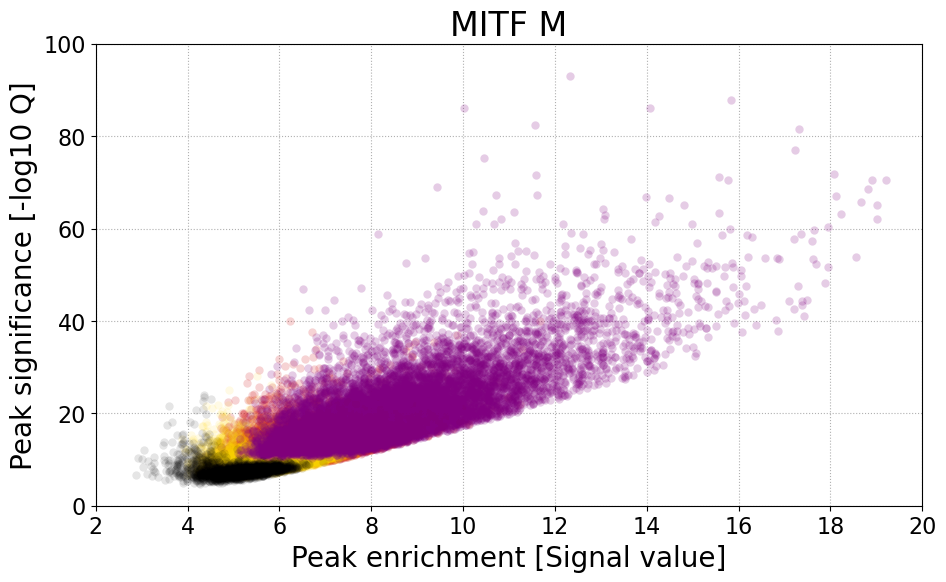

In [9]:
signal_threshold = 5         # encode signal
significance_threshold = 10  # encode significance threshold

# Boolean flags: does replicate i pass both thresholds?
pass_r1 = (df[3] >= signal_threshold) & (df[4] >= significance_threshold)
pass_r2 = (df[5] >= signal_threshold) & (df[6] >= significance_threshold)
pass_r3 = (df[7] >= signal_threshold) & (df[8] >= significance_threshold)

# Count how many replicates pass per row
pass_count = (pandas.concat([pass_r1, pass_r2, pass_r3], axis=1).sum(axis=1))

# arrange
df_black  = df.loc[pass_count == 0].copy()  # none pass
df_yellow = df.loc[pass_count == 1].copy()  # exactly one passes
df_orange = df.loc[pass_count == 2].copy()  # exactly two pass
df_red    = df.loc[pass_count == 3].copy()  # all three pass

print(df_red.shape)
print(df_orange.shape)
print(df_yellow.shape)
print(df_black.shape)

# plot
matplotlib.pyplot.plot(df_orange['signal'], df_orange['Q'], 'o', color='tab:red', alpha=0.2, mec='none')
matplotlib.pyplot.plot(df_yellow['signal'], df_yellow['Q'], 'o', color='gold', alpha=0.1, mec='none')
matplotlib.pyplot.plot(df_red['signal'], df_red['Q'], 'o', color='purple', alpha=0.2, mec='none')
matplotlib.pyplot.plot(df_black['signal'], df_black['Q'], 'o', color='black', alpha=0.1, mec='none')

matplotlib.pyplot.xlabel('Peak enrichment [Signal value]')
matplotlib.pyplot.ylabel('Peak significance [-log10 Q]')
matplotlib.pyplot.grid(ls=':')


matplotlib.pyplot.xlim(2, 20)
matplotlib.pyplot.ylim(0, 100)

matplotlib.pyplot.title('MITF M')

matplotlib.pyplot.show()

In [10]:
print(df_red.shape)
df_red.to_csv(output_dir+'purple.m.bed', header=False, index=False, sep='\t')

df_combined = pandas.concat([df_red, df_orange], ignore_index=True)
print(df_combined.shape)
df_combined.to_csv(output_dir+'orange.m.bed', header=False, index=False, sep='\t')

df_combined = pandas.concat([df_red, df_orange, df_yellow], ignore_index=True)
print(df_combined.shape)
df_combined.to_csv(output_dir+'gold.m.bed', header=False, index=False, sep='\t')

df_combined = pandas.concat([df_red, df_orange, df_yellow, df_black], ignore_index=True)
print(df_combined.shape)
df_combined.to_csv(output_dir+'black.m.bed', header=False, index=False, sep='\t')

(12316, 11)
(20930, 11)
(26706, 11)
(28921, 11)
